In [2]:
import warnings
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, LabelEncoder, OneHotEncoder
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import RandomizedSearchCV

from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix

from imblearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Data Acquisition

In [3]:
os.chdir('d:/Repository/homecredit_credit_scoring_model/dataset')
warnings.filterwarnings('ignore')


In [4]:
df = pd.read_csv('application_train.csv')

# Exploratory Data Analysis (EDA) & Cleaning

In [5]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
amt = [
    "AMT_ANNUITY",
    "AMT_CREDIT",
    "AMT_GOODS_PRICE",
    "AMT_INCOME_TOTAL"
]

amt_req_credit_bureau = [
    "AMT_REQ_CREDIT_BUREAU_DAY",
    "AMT_REQ_CREDIT_BUREAU_HOUR",
    "AMT_REQ_CREDIT_BUREAU_MON",
    "AMT_REQ_CREDIT_BUREAU_QRT",
    "AMT_REQ_CREDIT_BUREAU_WEEK",
    "AMT_REQ_CREDIT_BUREAU_YEAR"
]

cnt = [
    "CNT_CHILDREN",
    "CNT_FAM_MEMBERS"
]

days = [
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "DAYS_ID_PUBLISH",
    "DAYS_LAST_PHONE_CHANGE",
    "DAYS_REGISTRATION"
]

social_circle = [
    "DEF_30_CNT_SOCIAL_CIRCLE",
    "DEF_60_CNT_SOCIAL_CIRCLE",
    "OBS_30_CNT_SOCIAL_CIRCLE",
    "OBS_60_CNT_SOCIAL_CIRCLE"
]

ext_source = [
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3"
]

flag_documents = [
    "FLAG_DOCUMENT_2",
    "FLAG_DOCUMENT_3",
    "FLAG_DOCUMENT_4",
    "FLAG_DOCUMENT_5",
    "FLAG_DOCUMENT_6",
    "FLAG_DOCUMENT_7",
    "FLAG_DOCUMENT_8",
    "FLAG_DOCUMENT_9",
    "FLAG_DOCUMENT_10",
    "FLAG_DOCUMENT_11",
    "FLAG_DOCUMENT_12",
    "FLAG_DOCUMENT_13",
    "FLAG_DOCUMENT_14",
    "FLAG_DOCUMENT_15",
    "FLAG_DOCUMENT_16",
    "FLAG_DOCUMENT_17",
    "FLAG_DOCUMENT_18",
    "FLAG_DOCUMENT_19",
    "FLAG_DOCUMENT_20",
    "FLAG_DOCUMENT_21"
]

flag_contact_info = [
    "FLAG_CONT_MOBILE",
    "FLAG_EMAIL",
    "FLAG_EMP_PHONE",
    "FLAG_MOBIL",
    "FLAG_PHONE",
    "FLAG_WORK_PHONE"
]

flag_assets = [
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY",
    "OWN_CAR_AGE"
]

name = [
    "NAME_CONTRACT_TYPE",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "NAME_HOUSING_TYPE",
    "NAME_INCOME_TYPE",
    "NAME_TYPE_SUITE"
]

region_city_match = [
    "LIVE_CITY_NOT_WORK_CITY",
    "LIVE_REGION_NOT_WORK_REGION",
    "REG_CITY_NOT_LIVE_CITY",
    "REG_CITY_NOT_WORK_CITY",
    "REG_REGION_NOT_LIVE_REGION",
    "REG_REGION_NOT_WORK_REGION"
]

region_rating = [
    "REGION_POPULATION_RELATIVE",
    "REGION_RATING_CLIENT",
    "REGION_RATING_CLIENT_W_CITY"
]

housing_features = [
    "APARTMENTS_AVG", "APARTMENTS_MEDI", "APARTMENTS_MODE",
    "BASEMENTAREA_AVG", "BASEMENTAREA_MEDI", "BASEMENTAREA_MODE",
    "COMMONAREA_AVG", "COMMONAREA_MEDI", "COMMONAREA_MODE",
    "ELEVATORS_AVG", "ELEVATORS_MEDI", "ELEVATORS_MODE",
    "ENTRANCES_AVG", "ENTRANCES_MEDI", "ENTRANCES_MODE",
    "FLOORSMAX_AVG", "FLOORSMAX_MEDI", "FLOORSMAX_MODE",
    "FLOORSMIN_AVG", "FLOORSMIN_MEDI", "FLOORSMIN_MODE",
    "LANDAREA_AVG", "LANDAREA_MEDI", "LANDAREA_MODE",
    "LIVINGAPARTMENTS_AVG", "LIVINGAPARTMENTS_MEDI", "LIVINGAPARTMENTS_MODE",
    "LIVINGAREA_AVG", "LIVINGAREA_MEDI", "LIVINGAREA_MODE",
    "NONLIVINGAPARTMENTS_AVG", "NONLIVINGAPARTMENTS_MEDI", "NONLIVINGAPARTMENTS_MODE",
    "NONLIVINGAREA_AVG", "NONLIVINGAREA_MEDI", "NONLIVINGAREA_MODE",
    "FONDKAPREMONT_MODE", "HOUSETYPE_MODE", "TOTALAREA_MODE", 
    "WALLSMATERIAL_MODE", "EMERGENCYSTATE_MODE"
]

years = [
    "YEARS_BEGINEXPLUATATION_AVG",
    "YEARS_BEGINEXPLUATATION_MEDI",
    "YEARS_BEGINEXPLUATATION_MODE",
    "YEARS_BUILD_AVG",
    "YEARS_BUILD_MEDI",
    "YEARS_BUILD_MODE"
]

misc = [
    "CODE_GENDER",
    "HOUR_APPR_PROCESS_START",
    "OCCUPATION_TYPE",
    "ORGANIZATION_TYPE",
    "WEEKDAY_APPR_PROCESS_START"
]

ids_and_target = [
    "SK_ID_CURR",
    "TARGET"
]

In [7]:
df[amt].head()

,AMT_ANNUITY,AMT_CREDIT,AMT_GOODS_PRICE,AMT_INCOME_TOTAL
0,24700.5,406597.5,351000.0,202500.0
1,35698.5,1293502.5,1129500.0,270000.0
2,6750.0,135000.0,135000.0,67500.0
3,29686.5,312682.5,297000.0,135000.0
4,21865.5,513000.0,513000.0,121500.0


In [8]:
df[amt].describe()

,AMT_ANNUITY,AMT_CREDIT,AMT_GOODS_PRICE,AMT_INCOME_TOTAL
count,307499.000000,3.075110e+05,3.072330e+05,3.075110e+05
mean,27108.573909,5.990260e+05,5.383962e+05,1.687979e+05
std,14493.737315,4.024908e+05,3.694465e+05,2.371231e+05
min,1615.500000,4.500000e+04,4.050000e+04,2.565000e+04
25%,16524.000000,2.700000e+05,2.385000e+05,1.125000e+05
50%,24903.000000,5.135310e+05,4.500000e+05,1.471500e+05
75%,34596.000000,8.086500e+05,6.795000e+05,2.025000e+05
max,258025.500000,4.050000e+06,4.050000e+06,1.170000e+08


In [9]:
df[amt].isna().sum()

AMT_ANNUITY          12
AMT_CREDIT            0
AMT_GOODS_PRICE     278
AMT_INCOME_TOTAL      0
dtype: int64

In [10]:
df[['TARGET'] + amt].corr()

,TARGET,AMT_ANNUITY,AMT_CREDIT,AMT_GOODS_PRICE,AMT_INCOME_TOTAL
TARGET,1.000000,-0.012817,-0.030369,-0.039645,-0.003982
AMT_ANNUITY,-0.012817,1.000000,0.770138,0.775109,0.191657
AMT_CREDIT,-0.030369,0.770138,1.000000,0.986968,0.156870
AMT_GOODS_PRICE,-0.039645,0.775109,0.986968,1.000000,0.159610
AMT_INCOME_TOTAL,-0.003982,0.191657,0.156870,0.159610,1.000000


In [11]:
df[amt_req_credit_bureau].head()

,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_YEAR
0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0
3,NaN,NaN,NaN,NaN,NaN,NaN
4,0.0,0.0,0.0,0.0,0.0,0.0


In [12]:
df[amt_req_credit_bureau].describe()

,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_YEAR
count,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,0.007000,0.006402,0.267395,0.265474,0.034362,1.899974
std,0.110757,0.083849,0.916002,0.794056,0.204685,1.869295
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,9.000000,4.000000,27.000000,261.000000,8.000000,25.000000


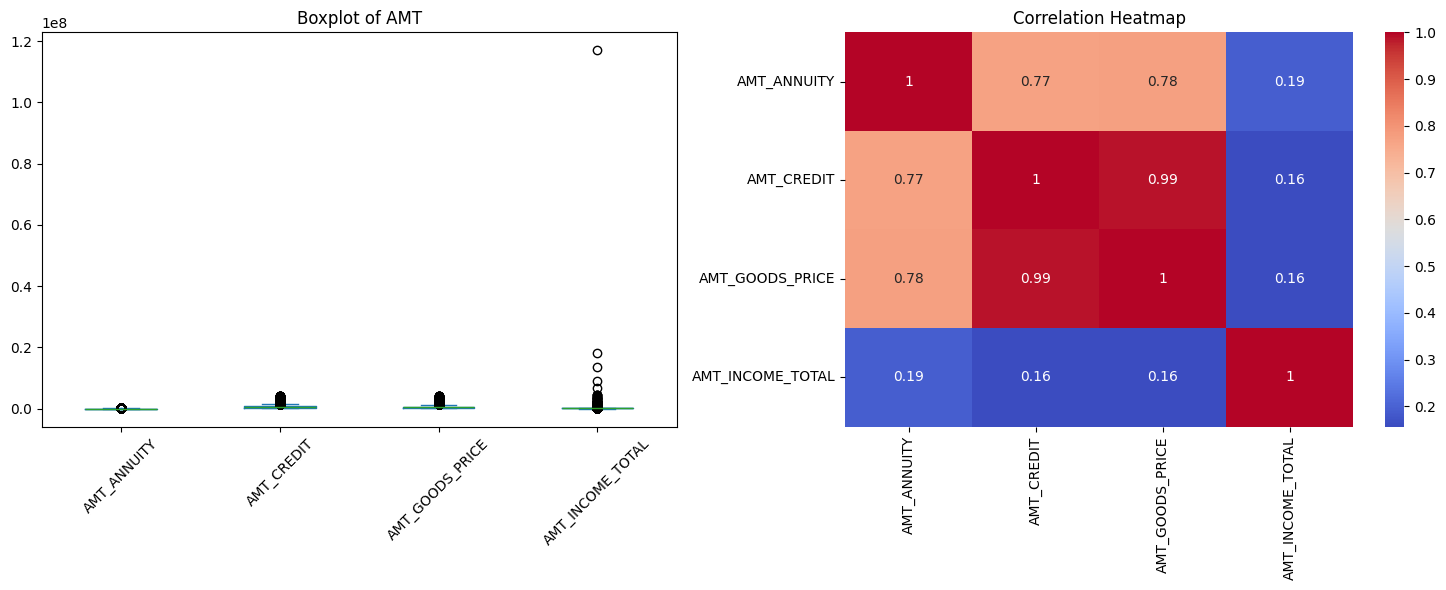

In [35]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

df[amt].plot(kind='box', ax=ax[0], rot=45)
ax[0].set_title('Boxplot of AMT')

sns.heatmap(df[amt].corr(), annot=True, cmap='coolwarm', ax=ax[1])
ax[1].set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()

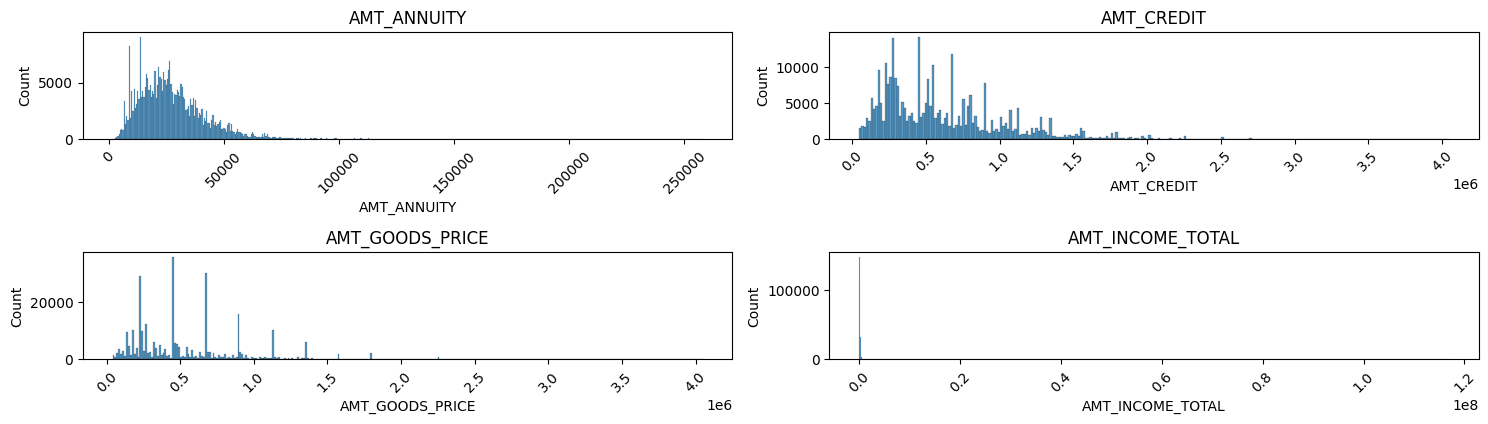

In [36]:
plt.figure(figsize=(15, 6))
for i, col in enumerate(df[amt].columns):
    plt.subplot(3, 2, i+1)
    sns.histplot(x=col, data=df)
    plt.xticks(rotation=45)
    plt.title(col)
plt.tight_layout()
plt.show()

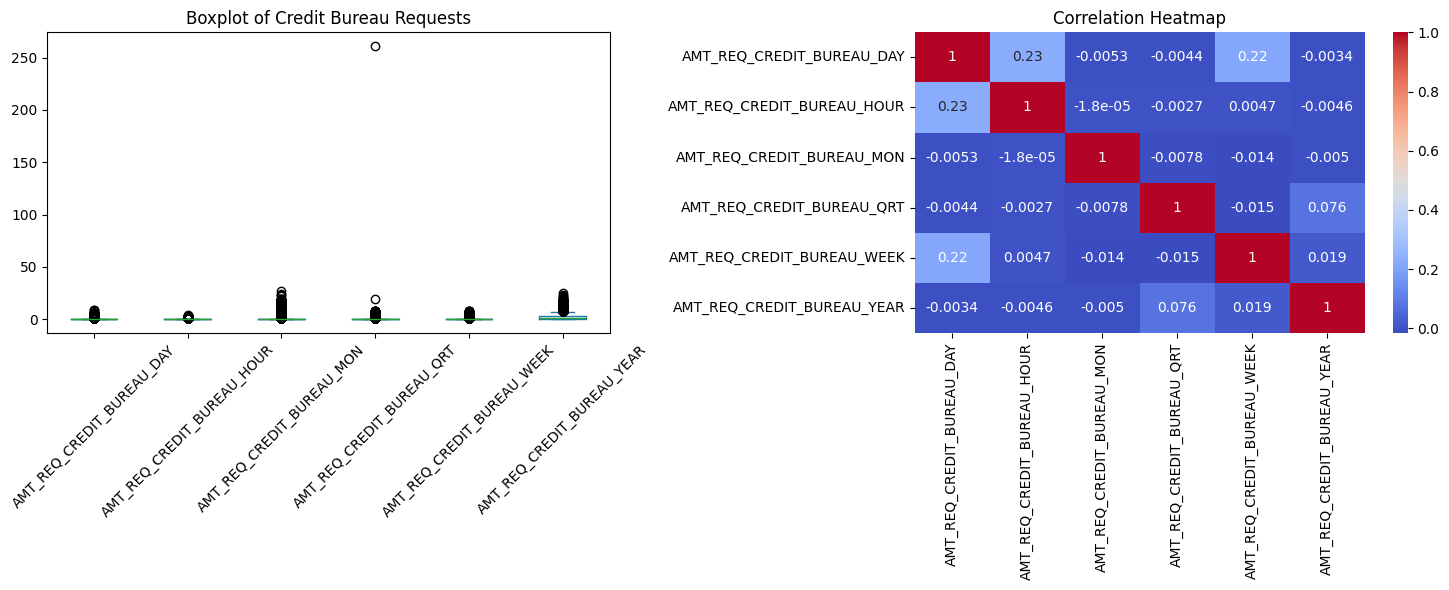

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

df[amt_req_credit_bureau].plot(kind='box', ax=ax[0], rot=45)
ax[0].set_title('Boxplot of Credit Bureau Requests')

sns.heatmap(df[amt_req_credit_bureau].corr(), annot=True, cmap='coolwarm', ax=ax[1])
ax[1].set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()

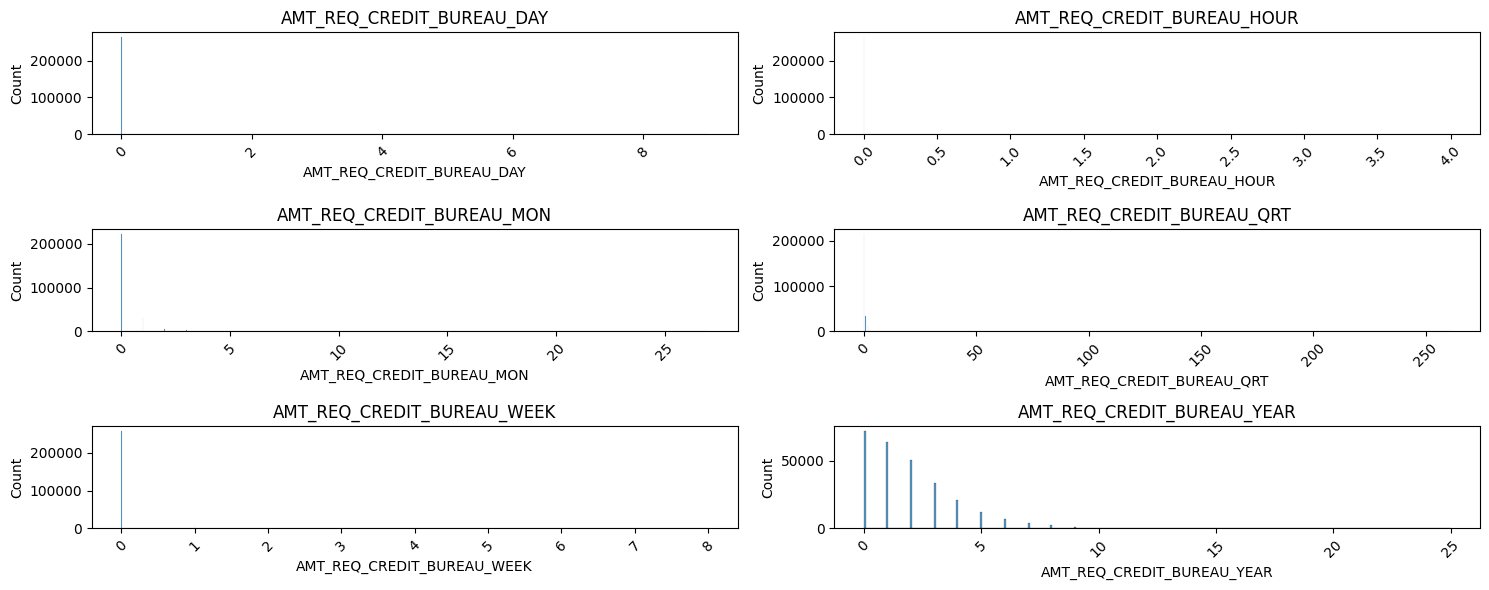

In [31]:
plt.figure(figsize=(15, 6))
for i, col in enumerate(df[amt_req_credit_bureau].columns):
    plt.subplot(3, 2, i+1)
    sns.histplot(x=col, data=df)
    plt.xticks(rotation=45)
    plt.title(col)
plt.tight_layout()
plt.show()

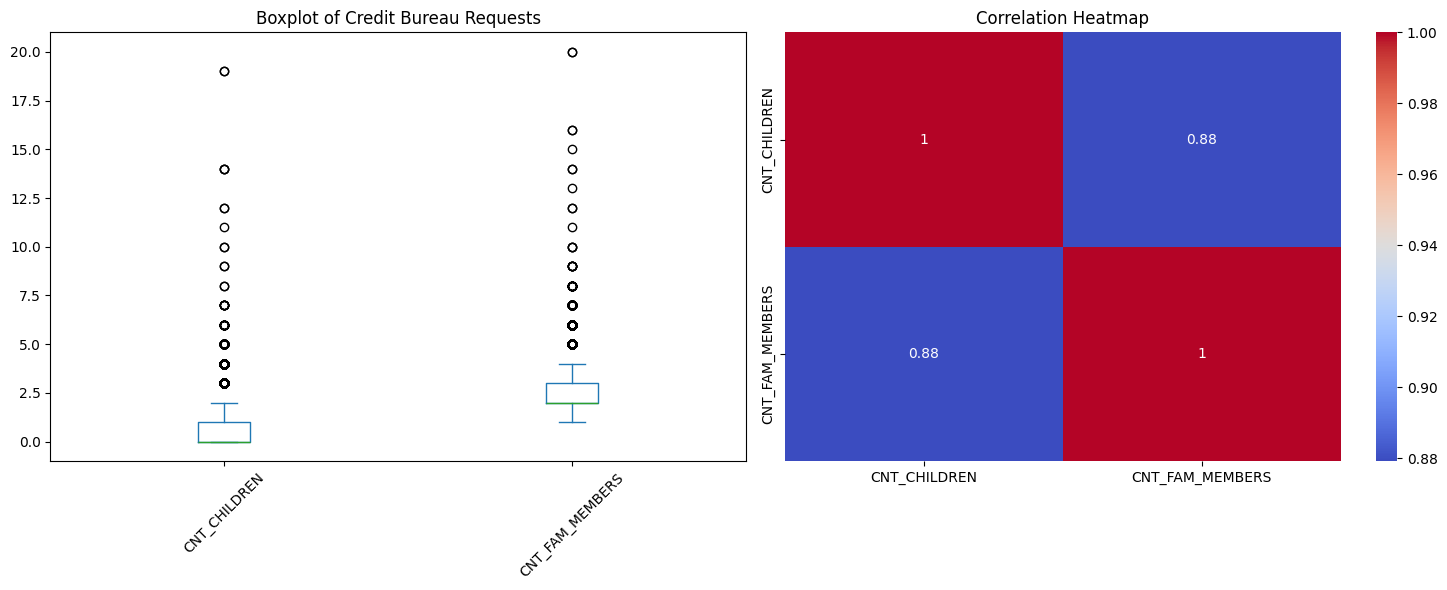

In [38]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

df[cnt].plot(kind='box', ax=ax[0], rot=45)
ax[0].set_title('Boxplot of Credit Bureau Requests')

sns.heatmap(df[cnt].corr(), annot=True, cmap='coolwarm', ax=ax[1])
ax[1].set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()

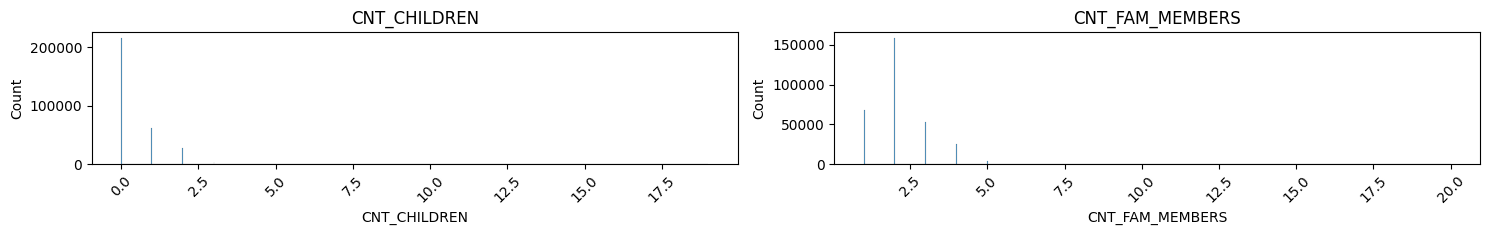

In [37]:
plt.figure(figsize=(15, 6))
for i, col in enumerate(df[cnt].columns):
    plt.subplot(3, 2, i+1)
    sns.histplot(x=col, data=df)
    plt.xticks(rotation=45)
    plt.title(col)
plt.tight_layout()
plt.show()

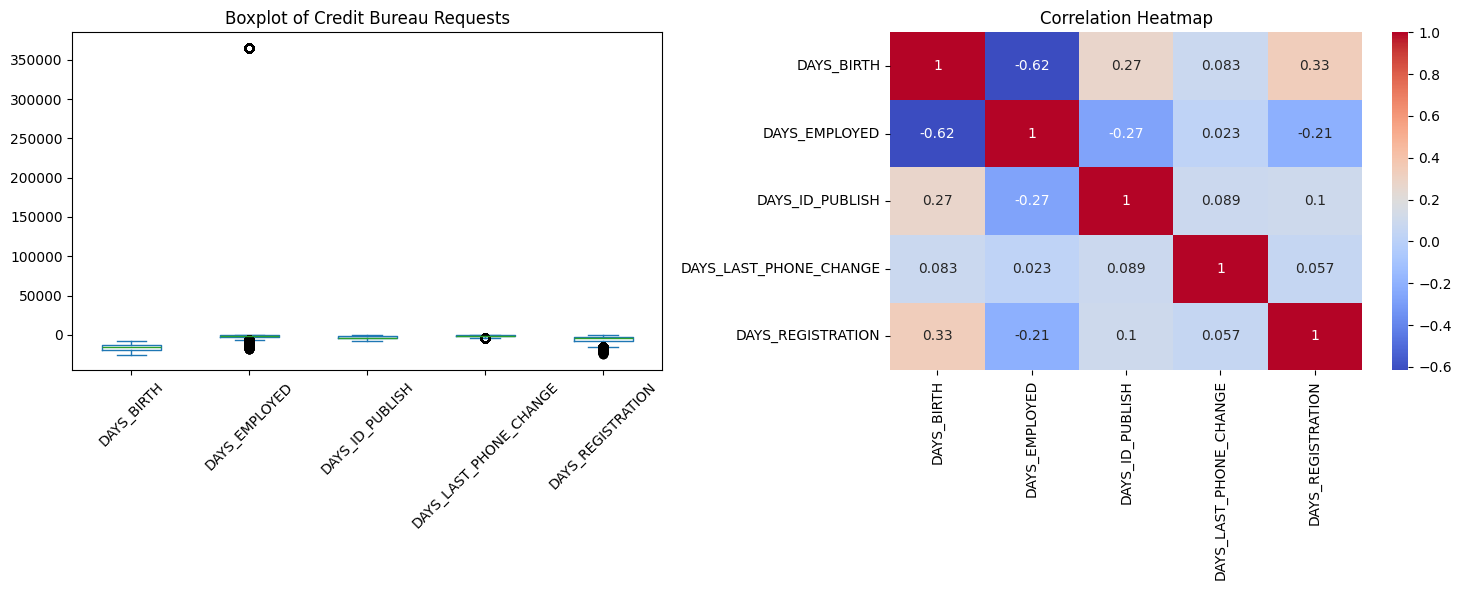

In [40]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

df[days].plot(kind='box', ax=ax[0], rot=45)
ax[0].set_title('Boxplot of Credit Bureau Requests')

sns.heatmap(df[days].corr(), annot=True, cmap='coolwarm', ax=ax[1])
ax[1].set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()

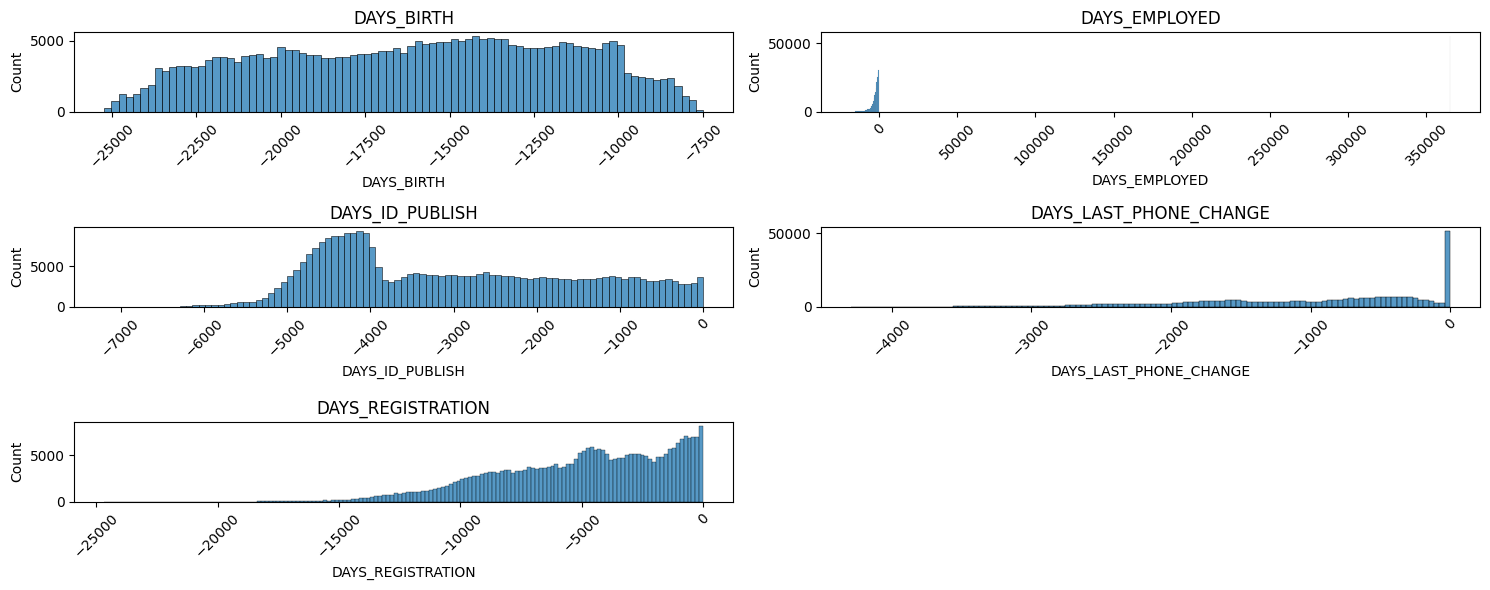

In [39]:
plt.figure(figsize=(15, 6))
for i, col in enumerate(df[days].columns):
    plt.subplot(3, 2, i+1)
    sns.histplot(x=col, data=df)
    plt.xticks(rotation=45)
    plt.title(col)
plt.tight_layout()
plt.show()

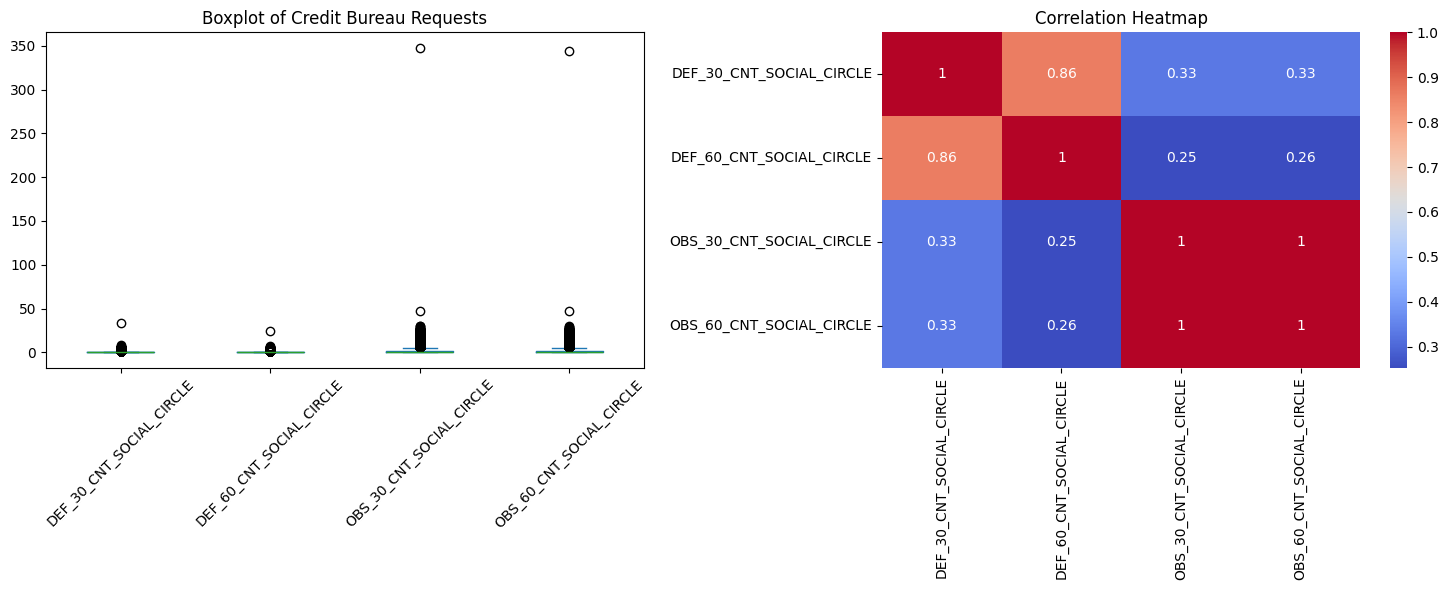

In [43]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

df[social_circle].plot(kind='box', ax=ax[0], rot=45)
ax[0].set_title('Boxplot of Credit Bureau Requests')

sns.heatmap(df[social_circle].corr(), annot=True, cmap='coolwarm', ax=ax[1])
ax[1].set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()

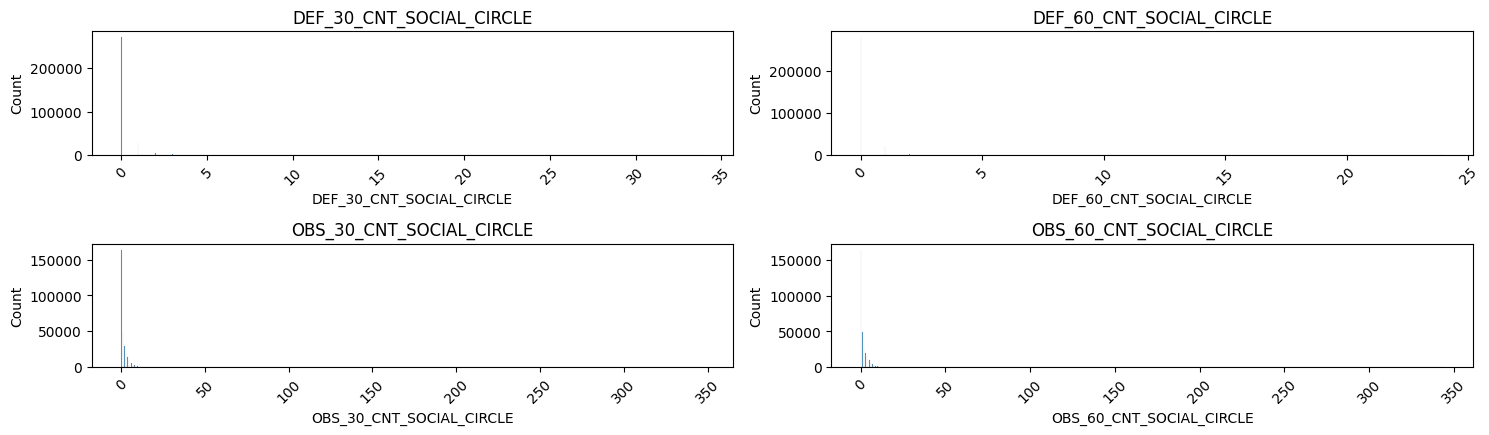

In [ ]:
plt.figure(figsize=(15, 6))
for i, col in enumerate(df[social_circle].columns):
    plt.subplot(3, 2, i+1)
    sns.histplot(x=col, data=df)
    plt.xticks(rotation=45)
    plt.title(col)
plt.tight_layout()
plt.show()

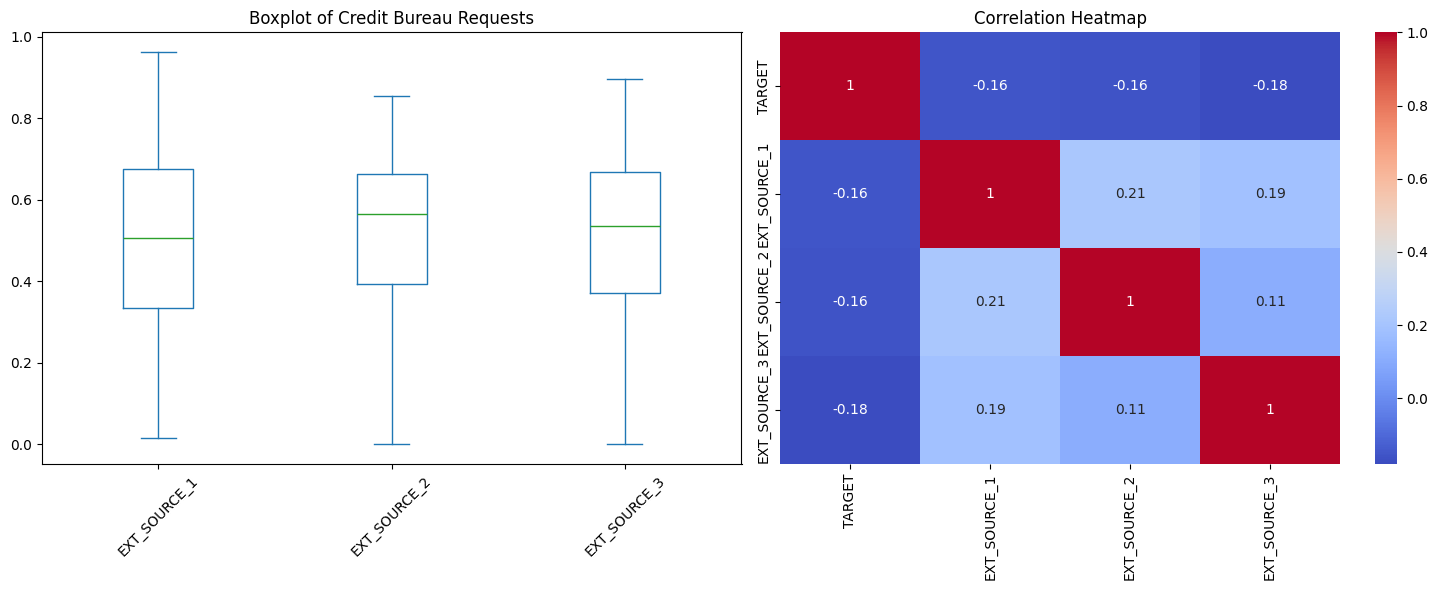

In [46]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

df[ext_source].plot(kind='box', ax=ax[0], rot=45)
ax[0].set_title('Boxplot of Credit Bureau Requests')

sns.heatmap(df[['TARGET'] + ext_source].corr(), annot=True, cmap='coolwarm', ax=ax[1])
ax[1].set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()

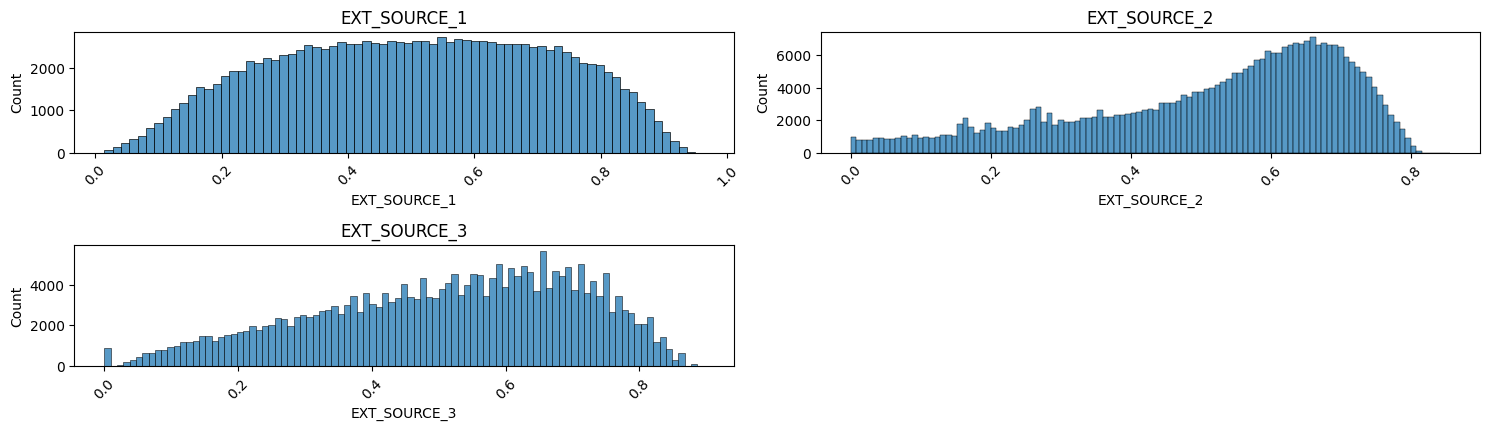

In [44]:
plt.figure(figsize=(15, 6))
for i, col in enumerate(df[ext_source].columns):
    plt.subplot(3, 2, i+1)
    sns.histplot(x=col, data=df)
    plt.xticks(rotation=45)
    plt.title(col)
plt.tight_layout()
plt.show()

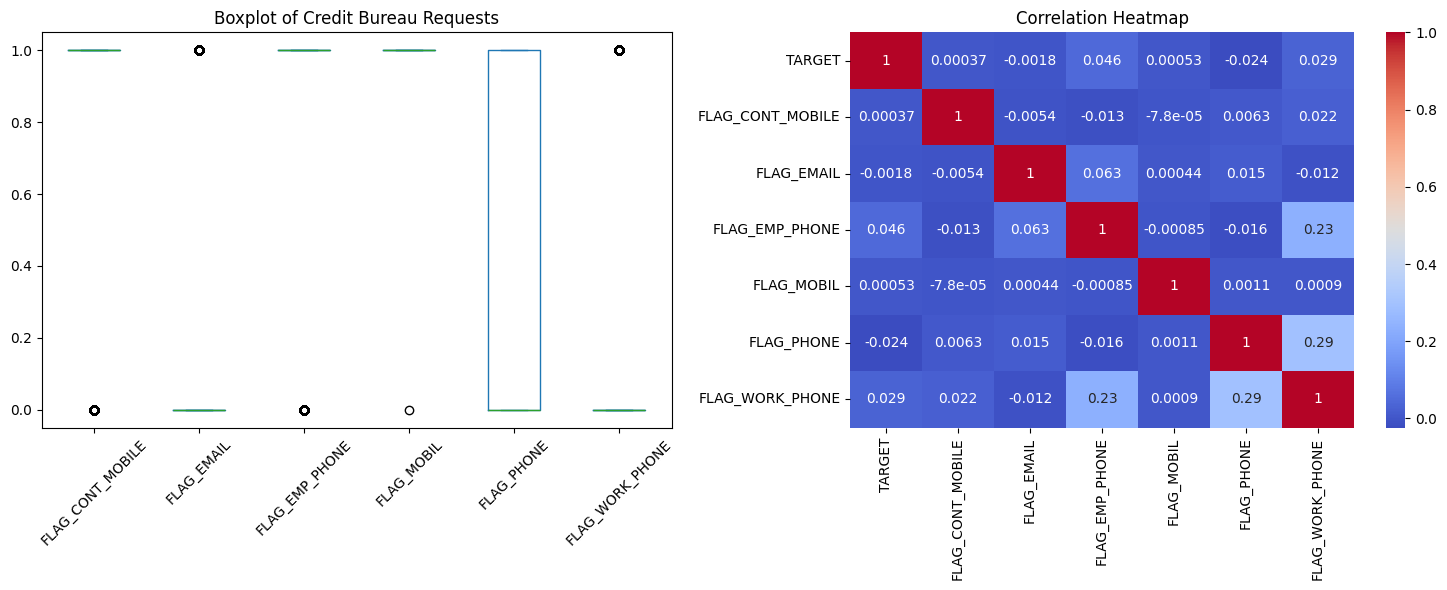

In [53]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

df[flag_contact_info].plot(kind='box', ax=ax[0], rot=45)
ax[0].set_title('Boxplot of Credit Bureau Requests')

sns.heatmap(df[['TARGET'] + flag_contact_info].corr(), annot=True, cmap='coolwarm', ax=ax[1])
ax[1].set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()

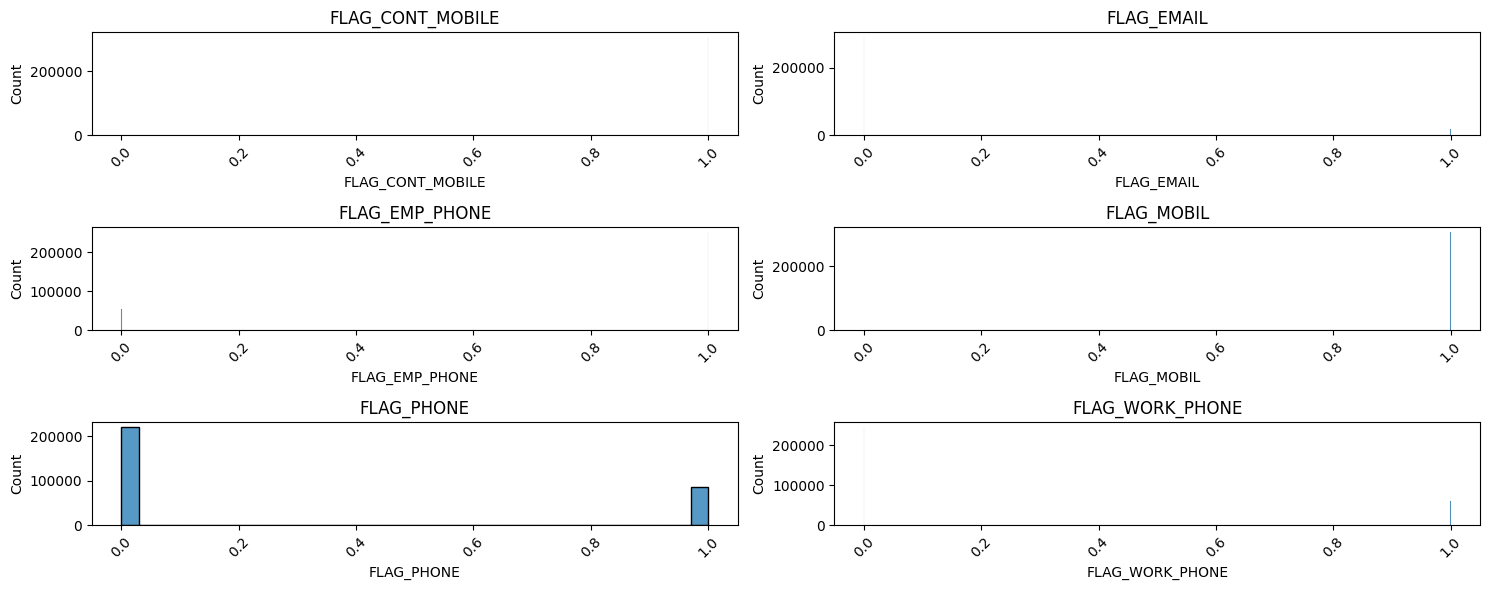

In [54]:
plt.figure(figsize=(15, 6))
for i, col in enumerate(df[flag_contact_info].columns):
    plt.subplot(3, 2, i+1)
    sns.histplot(x=col, data=df)
    plt.xticks(rotation=45)
    plt.title(col)
plt.tight_layout()
plt.show()

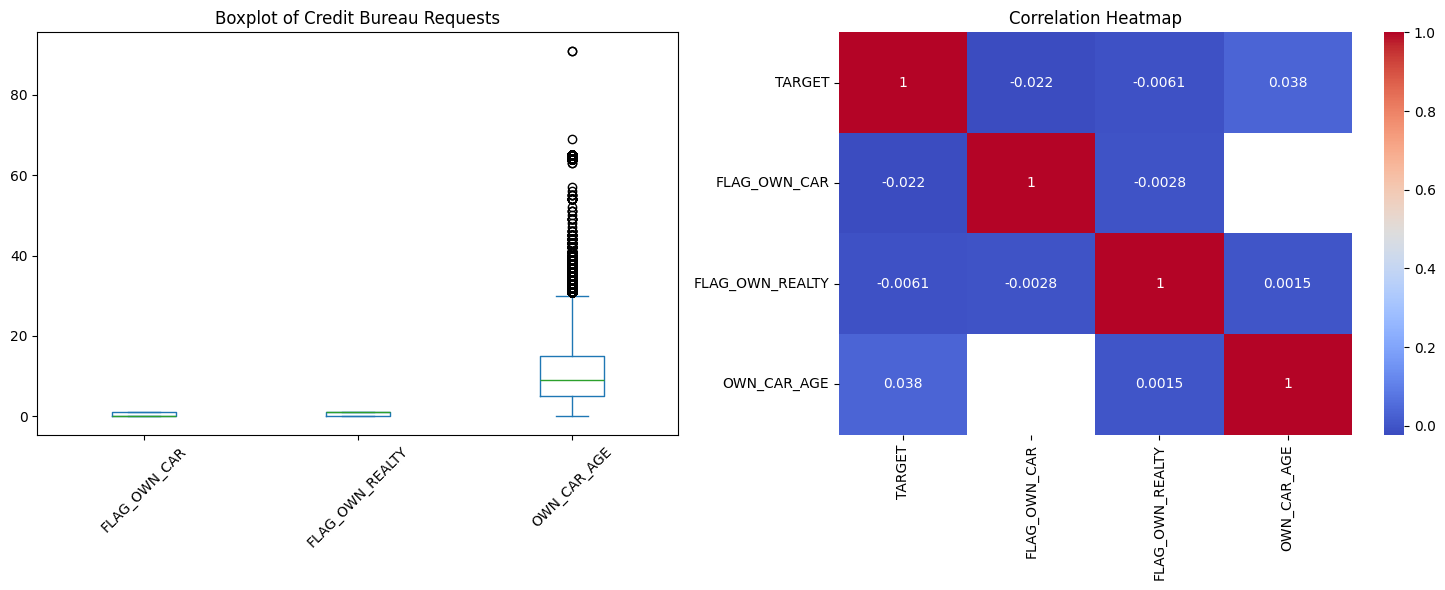

In [58]:
df['FLAG_OWN_CAR'] = df['FLAG_OWN_CAR'].map({'Y': 1, 'N': 0})
df['FLAG_OWN_REALTY'] = df['FLAG_OWN_REALTY'].map({'Y': 1, 'N': 0})

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

df[flag_assets].plot(kind='box', ax=ax[0], rot=45)
ax[0].set_title('Boxplot of Credit Bureau Requests')

sns.heatmap(df[['TARGET'] + flag_assets].corr(), annot=True, cmap='coolwarm', ax=ax[1])
ax[1].set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()

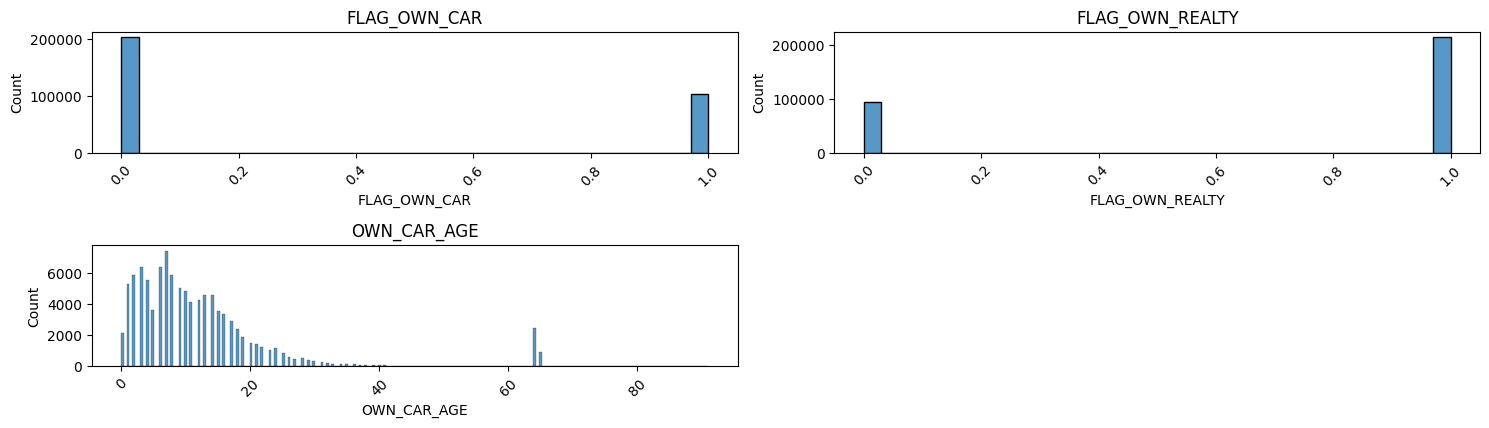

In [59]:
plt.figure(figsize=(15, 6))
for i, col in enumerate(df[flag_assets].columns):
    plt.subplot(3, 2, i+1)
    sns.histplot(x=col, data=df)
    plt.xticks(rotation=45)
    plt.title(col)
plt.tight_layout()
plt.show()

<Axes: >

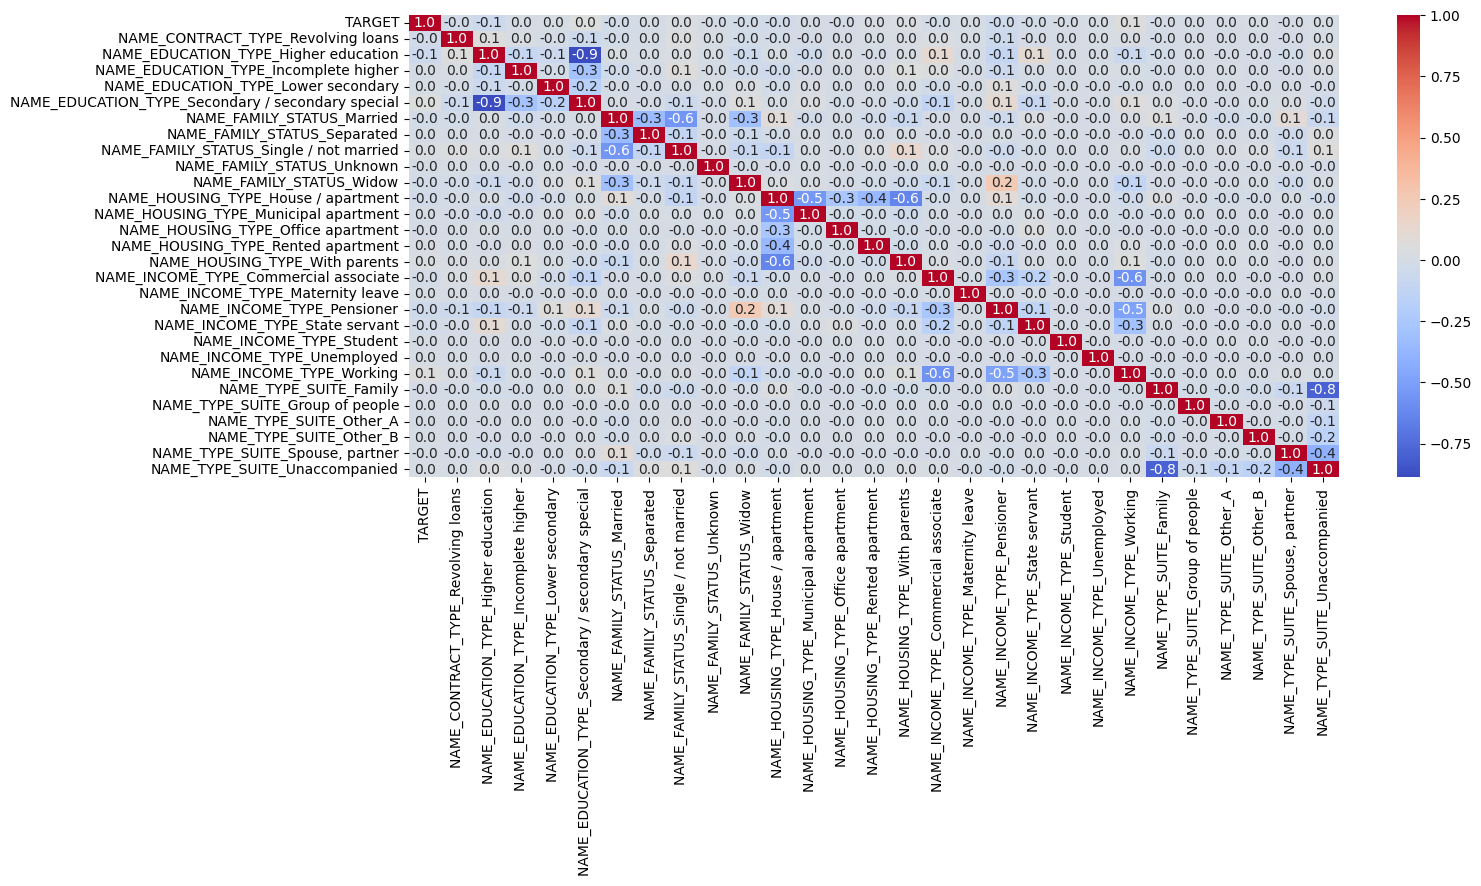

In [ ]:
dummies = pd.get_dummies(df, columns=name, drop_first=True, dtype=int)
new_dummy_cols = [col for col in dummies.columns if any(col.startswith(n) for n in name)]

plt.figure(figsize=(15, 6))
sns.heatmap(dummies[['TARGET'] + new_dummy_cols].corr(), annot=True, cmap='coolwarm', fmt='.1f')  


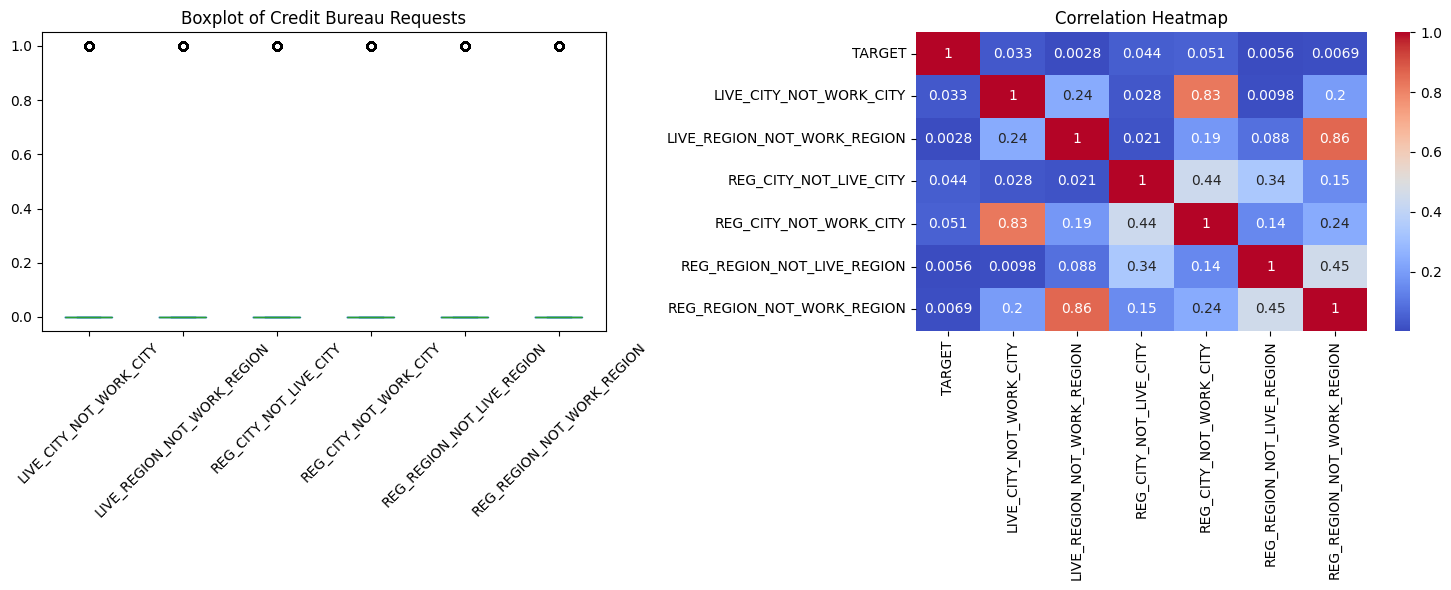

In [99]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

df[region_city_match].plot(kind='box', ax=ax[0], rot=45)
ax[0].set_title('Boxplot of Credit Bureau Requests')

sns.heatmap(df[['TARGET'] + region_city_match].corr(), annot=True, cmap='coolwarm', ax=ax[1])
ax[1].set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()

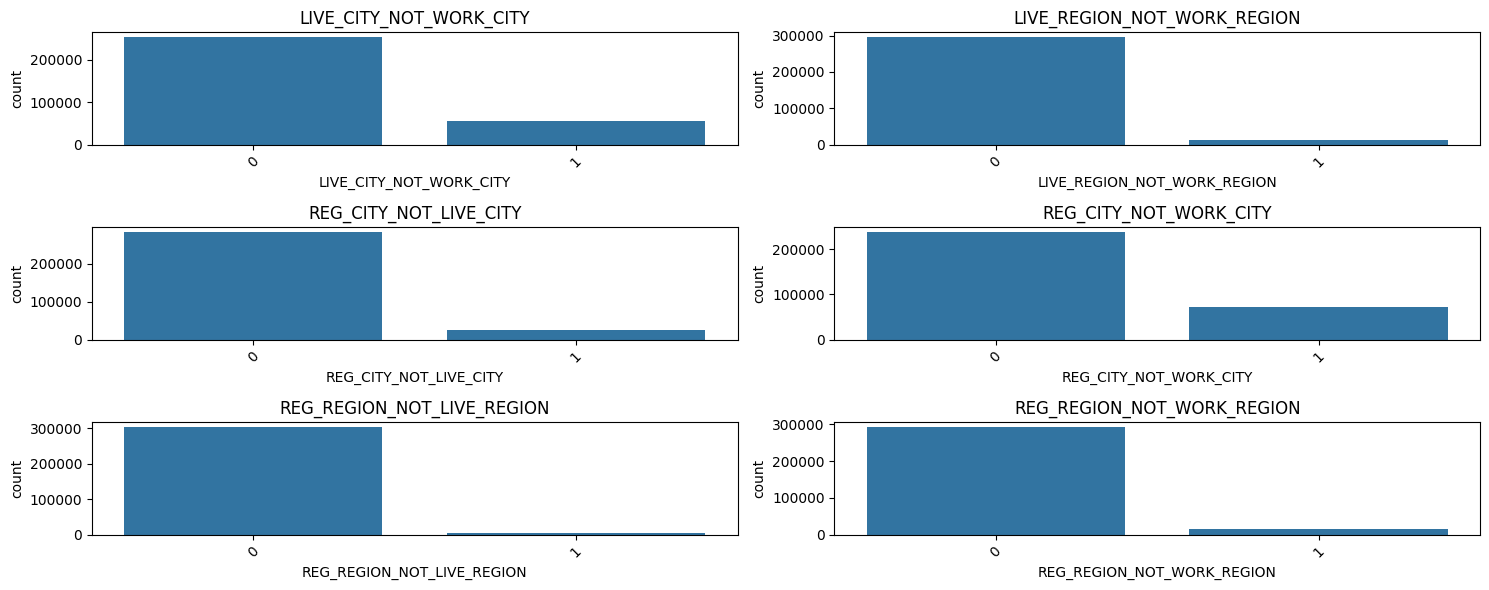

In [ ]:
plt.figure(figsize=(15, 6))
for i, col in enumerate(df[region_city_match].columns):
    plt.subplot(3, 2, i+1)
    sns.countplot(x=col, data=df)
    plt.xticks(rotation=45)
    plt.title(col)
plt.tight_layout()
plt.show()

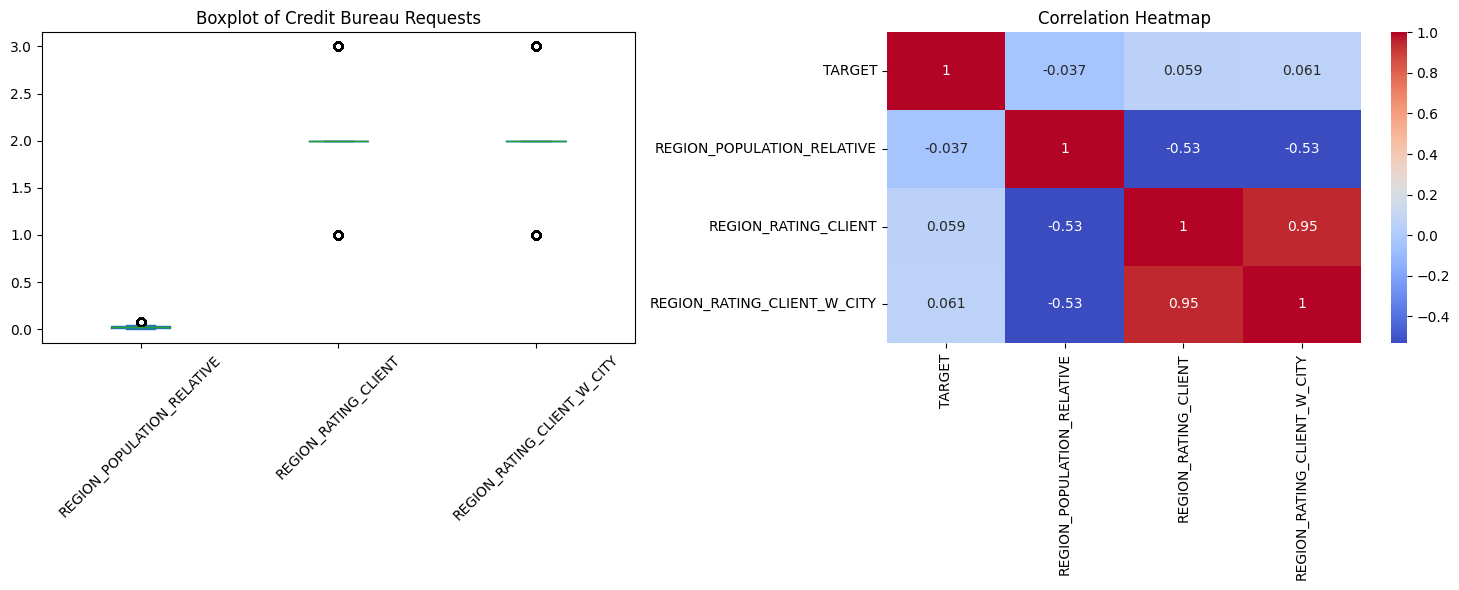

In [103]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

df[region_rating].plot(kind='box', ax=ax[0], rot=45)
ax[0].set_title('Boxplot of Credit Bureau Requests')

sns.heatmap(df[['TARGET'] + region_rating].corr(), annot=True, cmap='coolwarm', ax=ax[1])
ax[1].set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()

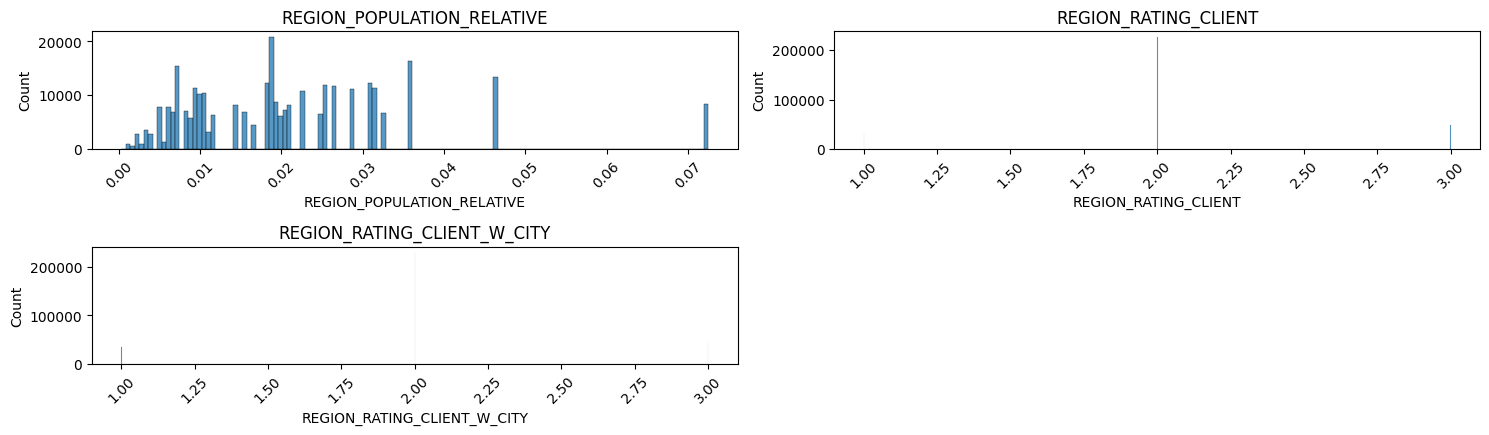

In [104]:
plt.figure(figsize=(15, 6))
for i, col in enumerate(df[region_rating].columns):
    plt.subplot(3, 2, i+1)
    sns.histplot(x=col, data=df)
    plt.xticks(rotation=45)
    plt.title(col)
plt.tight_layout()
plt.show()